# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

- **Métriques de référence (validation 2017)**
  - Matrice de confusion : tableau 2×2 (binaire) qui croise réel vs prédit. Les vraies métriques en dérivent.
   ```
                    Prédit 0          Prédit 1
    Réel 0     │     TN=2021        │      FP=11        │
    Réel 1     │     FN=351         │      TP=17        │
    ```
  - TN=2021 et TP=17 sont les vraies prédictions correctes.
  - FP=11 et FN=351 sont les erreurs.
  - total test = 2021 + 11 + 351 + 17 = 2400
  - Precision = TP / (TP + FP) = 0.6071 — « quand le modèle dit "défaut", il a raison 60,71% du temps ».
  - Recall = TP / (TP + FN) = 0.0462 — « le modèle détecte 4,62% des vrais défauts ».
  - F1 = 2 × (Precision × Recall) / (Precision + Recall) = 0.0859 — moyenne harmonique. Punit fort si l'un des deux est bas.
  - F1 macro : 0.5018302920210277 -> moyenne non pondérée des F1 pour chaque classe — donne autant de poids à la minorité qu'à la majorité. Utile pour mesurer la qualité globale quand on veut traiter défauts et remboursements de façon équilibrée. Sensible au choix du threshold.
  - ROC-AUC : 0.7296295949589181 -> aire sous la courbe ROC — probabilité que le modèle classe un défaut plus haut qu’un non‑défaut. Indique la capacité de discrimination indépendamment du threshold. Bon pour comparer modèles, mais ne renseigne pas sur le seuil opérationnel ni la calibration.
  - accuracy : = (2021 + 17) / 2400 = 0.8491666666666666 -> proportion de prédictions correctes. Simple mais trompeuse si classes déséquilibrées (ex. faible taux de défaut → accuracy élevée même pour un mauvais modèle). A ignorer pour nous car classe déséquilibrée
- **Features utilisées**
  - Numériques : `loan_amnt`, `int_rate`, `installment`, `annual_inc`, `dti`, `delinq_2yrs`, `fico_range_low`, `revol_util`
    - `loan_amnt` : montant du prêt, influence la taille de la dette.
    - `int_rate` : taux d'intérêt demandé ; un taux plus élevé signale généralement un profil plus risqué.
    - `installment` : montant des mensualités, important pour mesurer la charge de remboursement.
    - `annual_inc` : revenu annuel, indicateur clé de capacité à rembourser.
    - `dti` : ratio dette/revenu, mesure la pression financière.
    - `delinq_2yrs` : incidents de paiement passés, fort signal de risque.
    - `fico_range_low` : score de crédit minimum, indicateur de qualité de crédit.
    - `revol_util` : utilisation du crédit renouvelable, un taux élevé reflète une dépendance au crédit.
  - Catégorielles : `term`, `grade`, `emp_length`, `home_ownership`, `verification_status`, `purpose`
    - `term` : durée du prêt, un terme plus long peut augmenter le risque.
    - `grade` : note interne du dossier par Lending Club.
    - `emp_length` : ancienneté professionnelle, stabilité d'emploi.
    - `home_ownership` : statut du logement, peut affecter la solidité financière.
    - `verification_status` : vérification du revenu, un signal de confiance.
    - `purpose` : utilisation du prêt, certaines finalités sont plus risquées.
- **Architecture du modèle**
  - `Pipeline` scikit-learn avec :
    1. `preprocess` :
       - numériques → imputation par la médiane + standardisation
       - catégoriques → imputation par la modalité la plus fréquente + one-hot encoding
    2. `classifier` : `RandomForestClassifier`
  - Configurations testées dans `src/train.py` :
    - `default` : `n_estimators=100`, `random_state=42`
    - `balanced` : `n_estimators=200`, `max_depth=10`, `min_samples_leaf=10`, `class_weight='balanced'`, `random_state=42`

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

Nouveau dataset : (24000, 16)
Dataset 2017 : (12000, 16)
Colonnes identiques : True

Valeurs manquantes (nouveau dataset) :
emp_length    953
revol_util    391
dtype: int64

Déséquilibre des classes (nouveau dataset) :
loan_status
Fully Paid     0.816125
Charged Off    0.183875
Name: ratio, dtype: float64

Taux de défaut :
  nouveau dataset : 18.39%
  dataset 2017 : 14.79%

Présence de variables sensibles : ['fico_range_low', 'annual_inc', 'home_ownership', 'emp_length']

Anomalies détectées :
  annual_inc <= 0 : 0
  int_rate <= 0 : 0
  fico_range_low < 300 : 0
  revol_util > 100 : 0


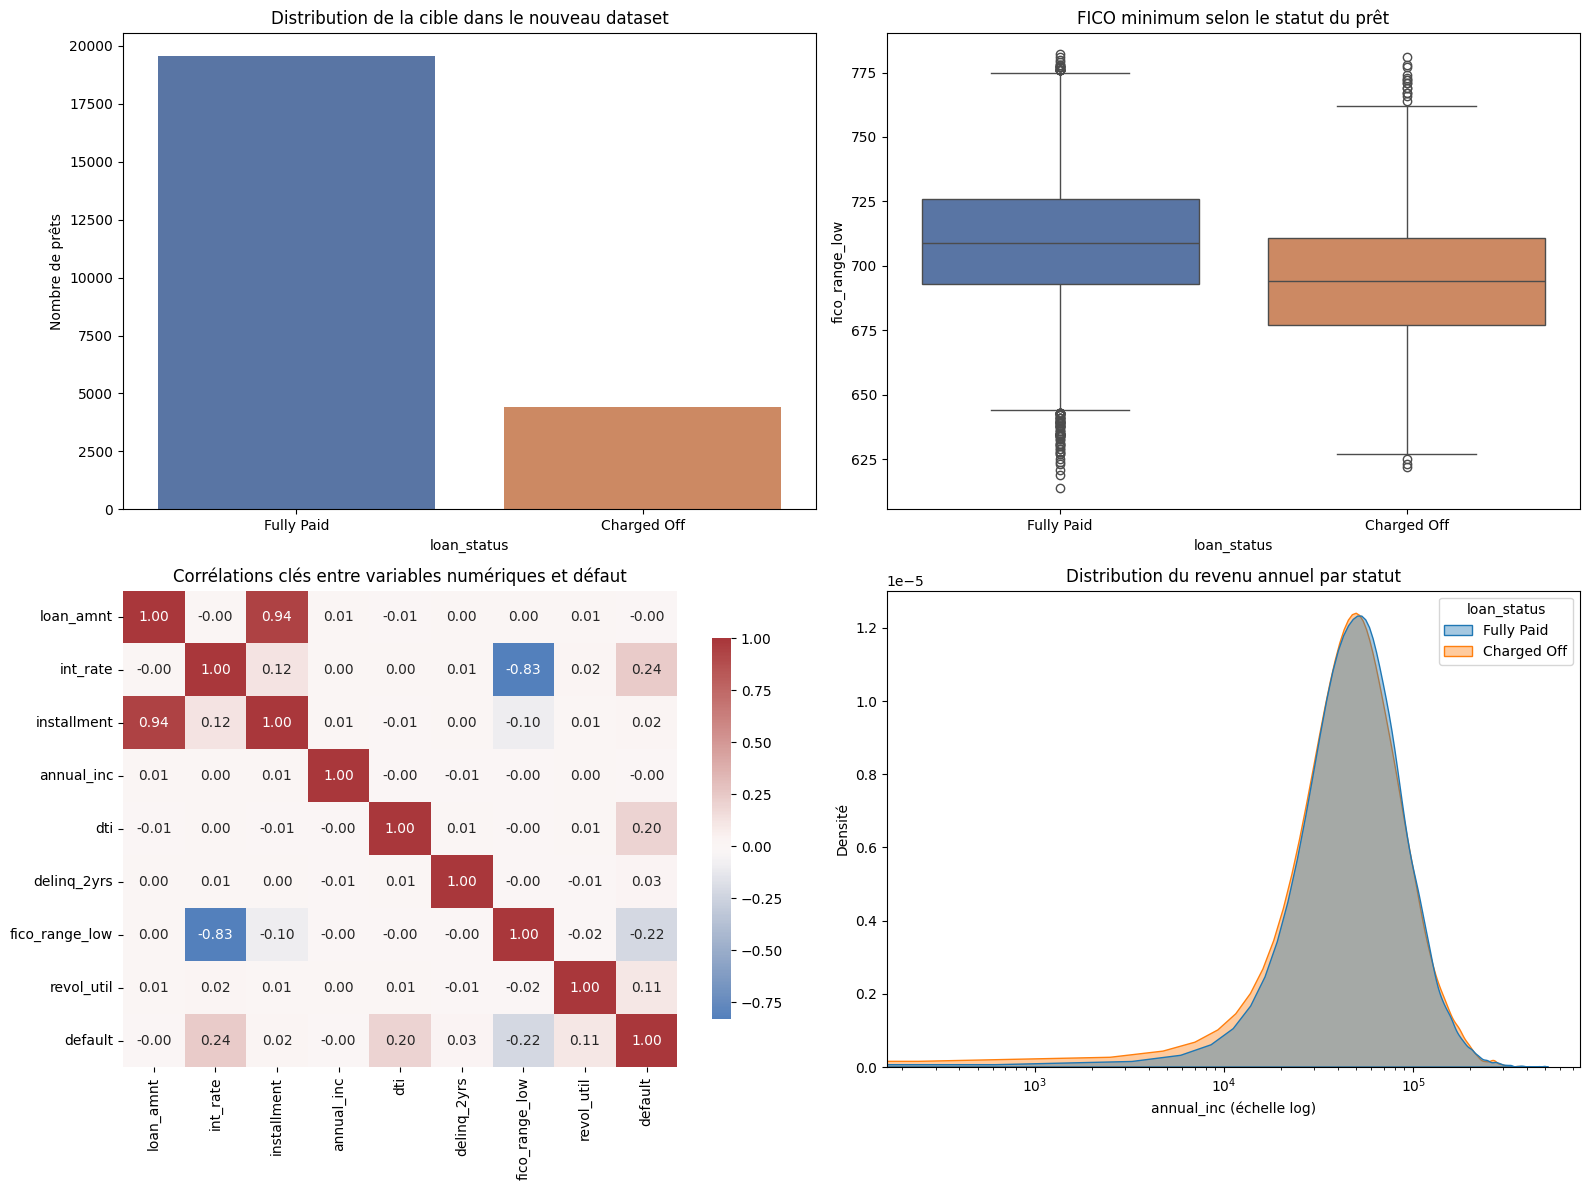

In [5]:
# Charge le nouveau dataset d'entraînement
# et le sous-ensemble 2017 (baseline) pour la comparaison.
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv', dtype={"loan_amnt": "int64", "term": "str", "int_rate": "float64", "installment": "float64", "grade": "str", "emp_length": "str", "home_ownership": "str", "annual_inc": "Int64", "verification_status": "str", "purpose": "str", "dti": "float64", "delinq_2yrs": "Int64", "fico_range_low": "Int64", "revol_util": "float64", "loan_status": "str"})
df2017 = pd.read_csv(DATA_DIR / 'lending_club_2017_subset.csv')

# Ajoute une colonne binaire `default` pour indiquer si le prêt a été "Charged Off".
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)
df2017['default'] = (df2017['loan_status'] == 'Charged Off').astype(int)

# Affiche les tailles des deux datasets pour vérifier l'échelle des jeux de données.
print('Nouveau dataset :', df.shape)
print('Dataset 2017 :', df2017.shape)

# Vérifie que les colonnes sont identiques entre le nouveau dataset et le dataset 2017 (baseline).
print('Colonnes identiques :', set(df.columns) == set(df2017.columns))

# Compte les valeurs manquantes pour les 10 colonnes les plus affectées.
na_counts = df.isna().sum().sort_values(ascending=False).head(10)
na_counts = na_counts[na_counts != 0]
if not na_counts.empty:
    print('\nValeurs manquantes (nouveau dataset) :')
    print(na_counts)

# Calcule le déséquilibre des classes sur la cible `loan_status`.
print('\nDéséquilibre des classes (nouveau dataset) :')
print(df['loan_status'].value_counts(normalize=True).rename('ratio'))

# Affiche le taux de défaut pour le nouveau dataset et pour le dataset 2017.
print('\nTaux de défaut :')
print('  nouveau dataset :', f"{df['default'].mean():.2%}")
print('  dataset 2017 :', f"{df2017['default'].mean():.2%}")

# Indique quelles variables sensibles sont présentes dans ce dataset.
print('\nPrésence de variables sensibles :', ['fico_range_low', 'annual_inc', 'home_ownership', 'emp_length'])

# Recherche quelques anomalies simples sur les variables numériques.
print('\nAnomalies détectées :')
# vérifie que le revenu est positif
print('  annual_inc <= 0 :', (df['annual_inc'] <= 0).sum())
# vérifie que le taux d'intérêt est positif
print('  int_rate <= 0 :', (df['int_rate'] <= 0).sum())
# vérifie que le score FICO est dans une plage réaliste
print('  fico_range_low < 300 :', (df['fico_range_low'] < 300).sum())
# vérifie que le taux d'utilisation du crédit renouvelable est inférieur ou égal à 100%
print('  revol_util > 100 :', pd.to_numeric(df['revol_util'], errors='coerce').gt(100).sum())

# Crée une figure 2x2 pour placer quatre visualisations sur une même page.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Comptage des prêts par statut pour visualiser l'équilibre de la cible.
sns.countplot(
    data=df,
    x='loan_status',
    order=['Fully Paid', 'Charged Off'],
    hue='loan_status',
    palette=['#4c72b0', '#dd8452'],
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title('Distribution de la cible dans le nouveau dataset')
axes[0, 0].set_xlabel('loan_status')
axes[0, 0].set_ylabel('Nombre de prêts')

# 2) Regarde comment le score FICO se répartit selon le statut du prêt.
sns.boxplot(
    data=df,
    x='loan_status',
    y='fico_range_low',
    hue='loan_status',
    palette=['#4c72b0', '#dd8452'],
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title('FICO minimum selon le statut du prêt')
axes[0, 1].set_xlabel('loan_status')
axes[0, 1].set_ylabel('fico_range_low')

# 3) Calcule la corrélation entre les variables numériques clés et la variable de défaut.
numeric_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util', 'default']
corr = df[numeric_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    cbar_kws={'shrink': 0.8},
    ax=axes[1, 0],
)
axes[1, 0].set_title('Corrélations clés entre variables numériques et défaut')

# 4) Compare la distribution du revenu annuel entre défauts et remboursements.
sns.kdeplot(
    data=df,
    x='annual_inc',
    hue='loan_status',
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[1, 1],
)
axes[1, 1].set_title('Distribution du revenu annuel par statut')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('annual_inc (échelle log)')
axes[1, 1].set_ylabel('Densité')

# Ajuste l'espacement entre les graphiques.
plt.tight_layout()
plt.show()

### Différences avec le dataset 2017

Le nouveau dataset est plus large que le sous-ensemble 2017 et contient plus de diversité dans les valeurs financières et catégorielles. Le schéma reste comparable, mais on note plusieurs éléments importants :

- le taux de défaut n’est pas exactement identique entre les deux jeux, ce qui montre que la distribution de la cible a pu évoluer ;
- le nouveau dataset contient davantage de valeurs manquantes sur des variables comme `emp_length` ou `revol_util`, ce qui renforce l’importance d’une imputation robuste ;
- les variables sensibles sont présentes et explicites : `fico_range_low`, `annual_inc`, `home_ownership`, `emp_length` ; elles doivent être traitées avec attention car elles peuvent introduire des biais ou des effets d’équité ;
- il n’y a pas de colonne d’état US explicite dans ces fichiers, donc la sensibilité géographique est moins évidente ici ;
- les corrélations montrent que `fico_range_low` et `annual_inc` restent des signaux forts, tandis que `int_rate` et `revol_util` sont aussi liés au défaut.

En résumé, le dataset nouveau reste cohérent avec la baseline 2017 en termes de colonnes, mais il est plus bruyant, plus riche en modalités et probablement plus difficile à modéliser sans un bon prétraitement.

### Explications mini-cours 02
F1 binaire (défaut) est plus bas que F1 macro. Pourquoi : F1 macro est la moyenne non pondérée des F1 par classe — il agrège donc la classe défaut (plus dure, F1 plus bas) et la classe remboursé (généralement plus facile à prédire, F1 plus haut). Cette moyenne reste meilleure que le seul F1 défaut, mais sans masquer la performance de la minorité comme le ferait l'accuracy ou le F1 weighted.

#### Informations supplémentaires

**Valeurs manquantes explications :**<br>
Seules deux colonnes ont des valeurs manquantes dans le top 10 : emp_length et revol_util.<br>
**emp_length** est probablement une information d'ancienneté d’emploi, NA = absent ou pas d'ancienneté<br>
**revol_util** est un ratio financier, NA = ?

**Déséquilibre des classes explications :**
- Classes désiquilibrées (mais pas extrême)
- Un modèle qui prédit toujours Fully Paid aurait déjà ~82% d’accuracy, donc l’accuracy n’est pas fiable.
- Privilégier des métriques robustes (F1 macro, ROC-AUC, matrice de confusion)

**Taux de défaut :**<br>
Le nouveau dataset a un taux de défaut plus élevé : 18.39% contre 14.79% en 2017.

**Variables sensibles explications :**
- **fico_range_low** : indicateur de score de crédit — corrélé à l’état socio‑économique et peut implicitement refléter appartenance à des groupes protégés. Peut introduire des biais discriminatoires.
- **annual_inc** : revenu annuel — information financière privée et un fort signal socio‑économique; usage direct peut désavantager certains groupes.
- **home_ownership** : statut de logement — lié à patrimoine/stabilité; peut agir comme proxy pour des caractéristiques protégées (âge, statut socio‑économique, etc.).
- **emp_length** : ancienneté professionnelle — mesure la stabilité d’emploi, peut être corrélée avec l’âge ou d’autres facteurs protégés.

**Anomalies détectées :**<br>
Pas d'amonalie détectée (cf commentaires dans le code).

## 3. Préparation et split

Split stratifié, `random_state=42`.

## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

In [14]:
import joblib, pandas as pd
pipeline = joblib.load("../models/pyrenex_risk_v2.joblib")
x_hold = pd.read_csv("../data/lending_club_holdout.csv").drop(columns=["loan_status"])
print(pipeline.predict_proba(x_hold.head(3))[0].tolist())

y_hold = (pd.read_csv("../data/lending_club_holdout.csv").drop(columns=["loan_status"]) == "Charged Off").astype(int)

[0.7903052440641742, 0.20969475593582512]


## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import sys
sys.path.append("..")  
from src.preprocess import build_preprocessor
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        x_hold, y_hold, test_size=0.2, stratify=y_hold, random_state=seed
    )
    pipeline_model = Pipeline(
        steps=[
            ("preprocess", build_preprocessor()),
            ("clf", RandomForestClassifier(
                n_estimators=250,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced_subsample",
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            )),
        ]
    )
    pipeline_model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, pipeline_model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


seed=   0 → F1 macro = 0.000


c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


seed=   1 → F1 macro = 0.000


c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


seed=  42 → F1 macro = 0.000


c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


seed= 100 → F1 macro = 0.000
seed=2024 → F1 macro = 0.000

Écart min-max : 0.000


c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.